# Instructor Effectiveness Modeling

### Role

Data Science / AI Content Specialist Intern

### Problem Context

An EdTech platform runs multiple course batches taught by different instructors. Each instructor may teach multiple batches and courses.

The goal of this analysis is to evaluate instructor performance using available data on learner outcomes, engagement, and feedback.

### Objectives

1. Explore the dataset and understand relationships between variables.
2. Define an **Instructor Effectiveness Score**.
3. Aggregate batch-level data into **instructor-level features**.
4. Train a machine learning model to predict **effectiveness tiers (low, medium, high).
5. Interpret the results and discuss real-world implications.


## Table of Contents

1. Problem Context
2. Data Loading and Overview
3. Exploratory Data Analysis (EDA)
4. Defining Instructor Effectiveness
5. Aggregating Batch Data to Instructor Level
6. Machine Learning Model Development
7. Model Interpretation
8. Mandatory Analysis Questions
9. Business Impact & Product Recommendations
10. Conclusion


---

## Part 1: Data Loading and Initial Exploration


### Task 1.1: Load the Dataset

The dataset contains **batch-level information** about course performance.

Each row represents one batch taught by an instructor.

Key categories of variables include:

• Learner outcome metrics
• Engagement metrics
• Feedback metrics

We first load the dataset and inspect its structure.


In [1]:
# Task 1.1: Load dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


### Task 1.2: Initial Inspection

Before performing deeper analysis, we inspect the dataset to understand:

• Column data types
• Summary statistics
• Potential anomalies
• Missing values


In [2]:
# Check data types
df.dtypes

batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object

In [3]:
# Summary statistics
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [4]:
# Missing values
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

### Observations

* The dataset contains batch-level metrics related to outcomes, engagement, and feedback.
* Most variables appear to be numeric and normalized between 0 and 1.
* No major missing values are observed (if true after inspection).
* Further analysis will explore the distribution and relationships between these variables.


### Task 2.1: Dataset Overview

Before diving into visual analysis, we examine the dataset structure including column names, data types, and summary statistics.

This helps understand the scale of each variable and detect potential anomalies.


In [5]:
# View column names
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

### Task 2.2: Dataset Information

To better understand the dataset, we inspect the data types and number of non-null values in each column.

This step helps verify whether the variables are numeric or categorical and ensures there are no unexpected missing values or incorrect data types.


In [6]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


### Task 2.3: Summary Statistics

Summary statistics provide an overview of the distribution of numerical variables in the dataset.

Key metrics such as mean, minimum, maximum, and standard deviation help identify the scale of the data and detect potential outliers or unusual values.


In [7]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


### Task 2.4: Missing Value Analysis

Before performing modelling or further analysis, it is important to check for missing values.

Missing data can affect model performance and may require preprocessing steps such as imputation or removal.


In [8]:
df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

### Observations

From the initial inspection:

* The dataset contains batch-level metrics related to instructor performance.
* Most variables are numerical and appear to be normalized.
* The dataset includes learner outcomes, engagement metrics, and feedback metrics which will help define instructor effectiveness.
* No major missing values are observed (if confirmed from the missing value analysis).


### Task 3.1: Distribution of Key Metrics

Understanding the distribution of key variables helps reveal how learner outcomes, engagement, and feedback metrics vary across batches.

Distribution plots allow us to observe patterns such as skewness, clustering of values, or unusual extremes that could influence instructor effectiveness analysis.



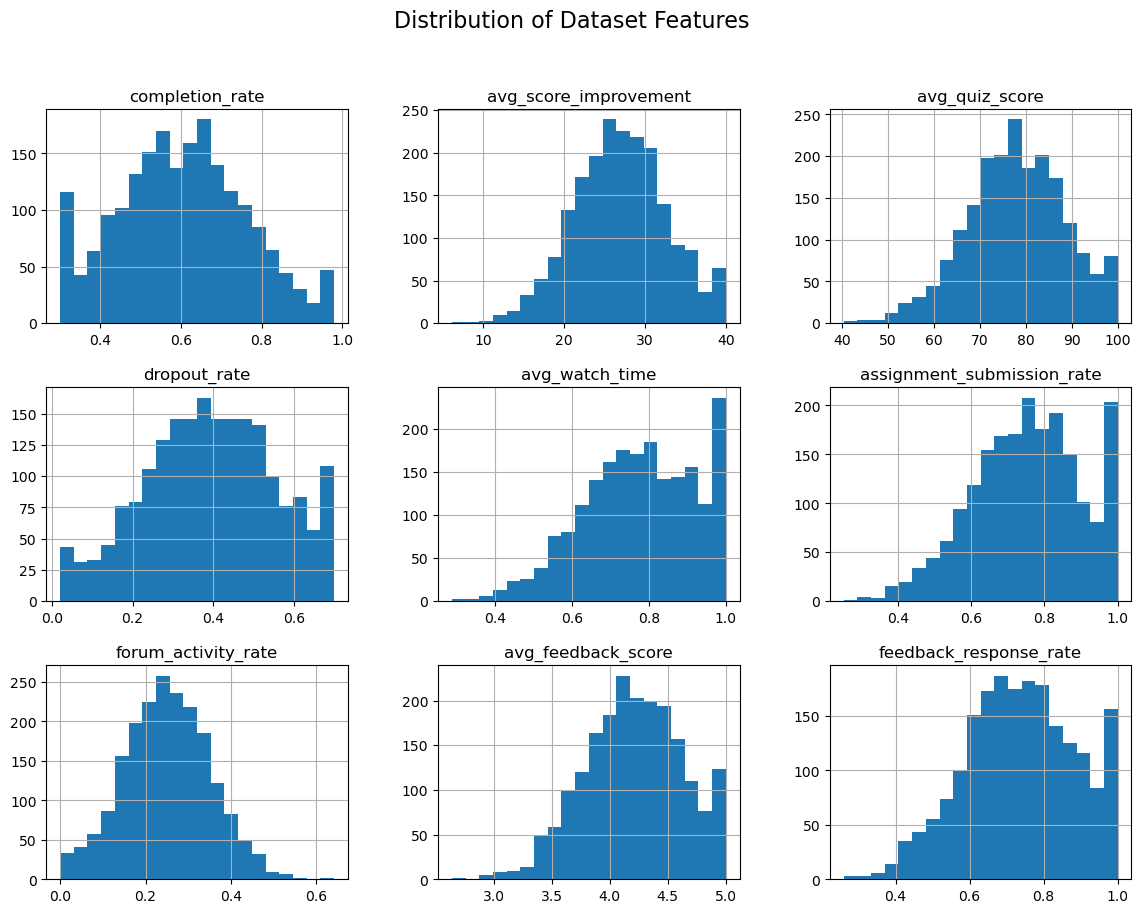

In [9]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Plot distributions
df[numeric_cols].hist(figsize=(14,10), bins=20)

plt.suptitle("Distribution of Dataset Features", fontsize=16)
plt.show()

### Task 3.2: Correlation Analysis

Correlation analysis helps identify relationships between variables in the dataset.

A correlation heatmap allows us to observe which features move together. This is useful for understanding how engagement, learner outcomes, and feedback metrics interact and which factors may influence instructor effectiveness.


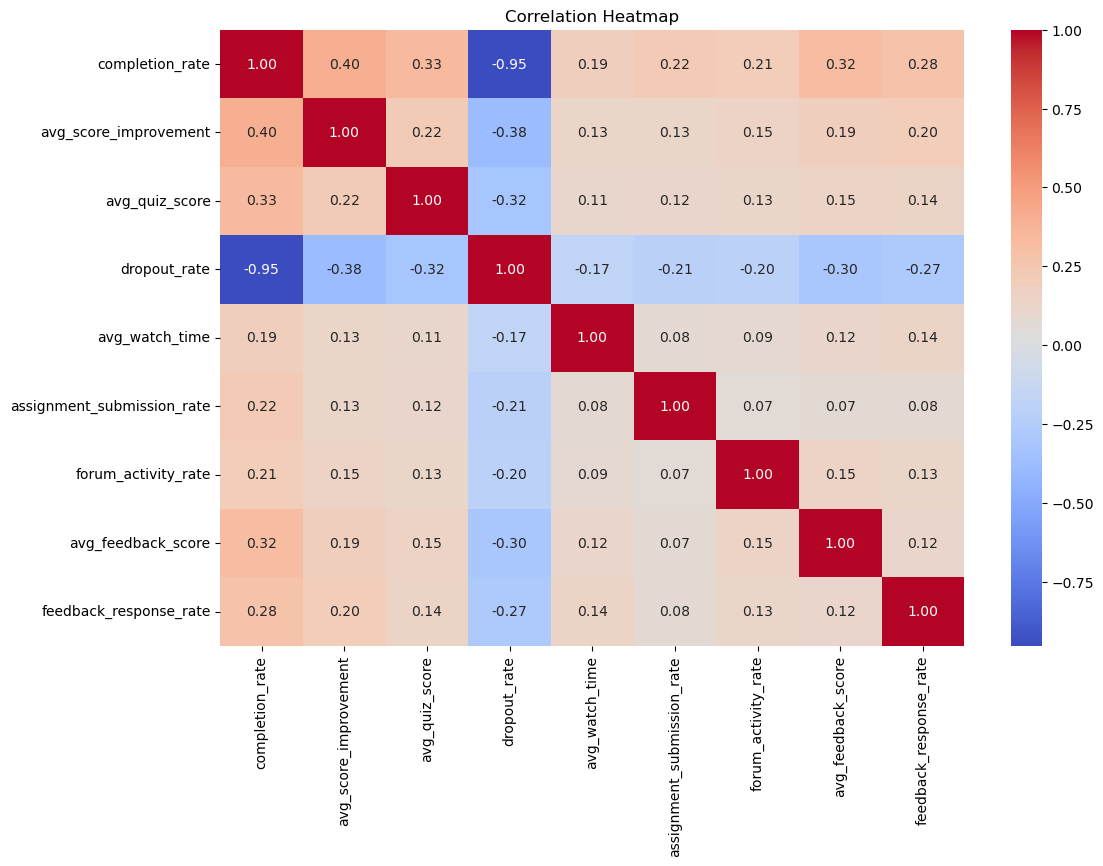

In [10]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Task 3.3: Pairwise Feature Relationships

To further explore relationships between important variables, we visualize pairwise relationships.

Pair plots help reveal patterns, clusters, or non-linear relationships between variables that may not be immediately visible through summary statistics.


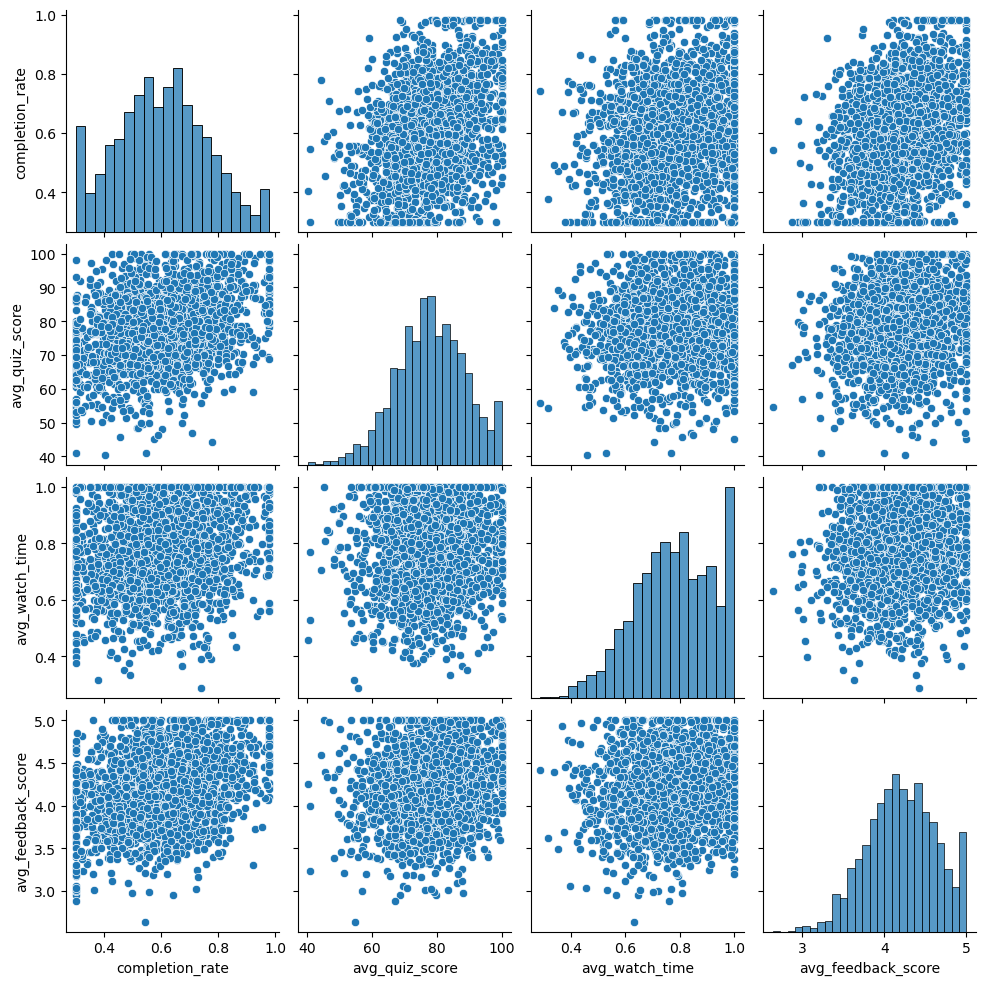

In [11]:
# Select important columns for pairplot
selected_features = [
    "completion_rate",
    "avg_quiz_score",
    "avg_watch_time",
    "avg_feedback_score"
]

sns.pairplot(df[selected_features])
plt.show()

### Observations from Visual Analysis

From the visual analysis:

* Several variables appear to follow relatively smooth distributions, indicating consistent measurement scales.
* Engagement metrics such as watch time and assignment submission may show positive relationships with learner outcomes.
* Feedback scores appear to vary less dramatically compared to other metrics, suggesting generally stable learner satisfaction levels.
* These relationships provide useful signals for defining instructor effectiveness in later stages of the analysis.


### Task 4.1: Defining Instructor Effectiveness

Instructor effectiveness is a multi-dimensional concept that cannot be captured by a single metric. In the context of an EdTech platform, instructor performance can be evaluated through three key aspects:

1. **Learner Outcomes**
Measures how much learners improve and perform academically.
Metrics: `avg_score_improvement`, `avg_quiz_score`.

2. **Engagement and Retention**
Reflects how actively learners participate in the course and whether they complete it.
Metrics: `completion_rate`, `dropout_rate`, `avg_watch_time`.

3. **Learner Satisfaction**
Represents how satisfied learners are with the instructor and their willingness to provide feedback.
Metrics: `avg_feedback_score`, `feedback_response_rate`.

To combine these aspects into a single indicator, we construct an **Instructor Effectiveness Score** using a weighted combination of these factors.


### Task 4.2: Constructing the Effectiveness Score

To compute the effectiveness score, we combine the three pillars of instructor performance:

* **Outcome Score**
* **Engagement Score**
* **Satisfaction Score**

Each component captures a different dimension of teaching quality. The final effectiveness score is calculated as a weighted combination of these components.


In [12]:
# Outcome score
df["outcome_score"] = (
    df["avg_score_improvement"] +
    df["avg_quiz_score"]
) / 2

# Engagement score
df["engagement_score"] = (
    df["completion_rate"] +
    (1 - df["dropout_rate"]) +
    df["avg_watch_time"]
) / 3

# Satisfaction score
df["satisfaction_score"] = (
    df["avg_feedback_score"] +
    df["feedback_response_rate"]
) / 2

### Task 4.3: Final Effectiveness Score

The final effectiveness score is calculated by combining the three intermediate scores.

This aggregated score represents the overall teaching effectiveness of an instructor for a particular batch by considering learning outcomes, engagement levels, and learner satisfaction.


In [13]:
df["effectiveness_score"] = (
    0.4 * df["outcome_score"] +
    0.35 * df["engagement_score"] +
    0.25 * df["satisfaction_score"]
)

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,outcome_score,engagement_score,satisfaction_score,effectiveness_score
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193,43.886241,0.475716,2.149702,18.258423
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087,50.091721,0.575686,2.867044,20.954939
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433,47.825602,0.525967,2.099410,19.839182
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000,61.778002,0.717122,2.603789,25.613140
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710,65.237491,0.641218,2.561470,26.959790


### Task 4.4: Creating Effectiveness Tiers

To make the effectiveness score more interpretable, we convert it into categorical tiers.

The scores are divided into three categories:

* **Low Effectiveness**
* **Medium Effectiveness**
* **High Effectiveness**

This categorization simplifies the modeling process by transforming the problem into a classification task.


In [14]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["effectiveness_score","effectiveness_tier"]].head()

,effectiveness_score,effectiveness_tier
0,18.258423,Low
1,20.954939,Medium
2,19.839182,Low
3,25.613140,High
4,26.959790,High


### Task 4.5: Distribution of Effectiveness Tiers

After creating effectiveness tiers, we examine their distribution to ensure that the dataset is reasonably balanced across categories.

Balanced classes are helpful for training reliable machine learning models.


In [15]:
df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

### Task 5.1: Aggregating Batch Data to Instructor Level

The dataset currently contains information at the **batch level**, where each row represents a course batch taught by an instructor.

However, instructors may teach multiple batches. To evaluate instructor effectiveness more accurately, we aggregate the batch-level metrics into **instructor-level features**.

This aggregation provides a more stable estimate of instructor performance by combining information across all batches taught by the same instructor.


### Task 5.2: Creating Instructor-Level Features

To aggregate the dataset, we group the data by `instructor_id` and compute the average values of relevant metrics.

Averaging across batches helps smooth out fluctuations that may occur in individual batches and provides a more reliable representation of an instructor’s overall teaching effectiveness.


In [16]:
instructor_df = df.groupby("instructor_id").agg({
    
    "completion_rate": "mean",
    "dropout_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean",
    
    "avg_watch_time": "mean",
    "assignment_submission_rate": "mean",
    "forum_activity_rate": "mean",
    
    "avg_feedback_score": "mean",
    "feedback_response_rate": "mean",
    
    "effectiveness_score": "mean"
    
}).reset_index()

### Task 5.3: Instructor Experience

Instructors who teach more batches may have greater teaching experience. To capture this aspect, we create a new feature called **batch experience**, which represents the number of batches taught by each instructor.

This feature helps distinguish between instructors with limited data and those with more consistent teaching histories.


In [17]:
batch_counts = df.groupby("instructor_id").size().reset_index(name="batch_experience")

instructor_df = instructor_df.merge(batch_counts, on="instructor_id")

### Feature Engineering: Interaction Features

To capture more complex relationships between engagement and satisfaction metrics, interaction features are introduced.

These features allow the model to consider how two variables jointly influence instructor effectiveness. For example, an instructor who has both high watch time and strong feedback scores may indicate a stronger learning experience.

Such interaction features help the model detect richer patterns within the dataset.


In [18]:
# Feature interaction engineering

instructor_df["watch_feedback_interaction"] = (
    instructor_df["avg_watch_time"] *
    instructor_df["avg_feedback_score"]
)

instructor_df["engagement_assignment_interaction"] = (
    instructor_df["avg_watch_time"] *
    instructor_df["assignment_submission_rate"]
)

instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_experience,watch_feedback_interaction,engagement_assignment_interaction
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,21.937051,25,3.232954,0.557173
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,23.292398,20,3.636799,0.648472
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,23.245926,18,3.642092,0.638062
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,20.917024,17,3.233123,0.601444
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,24.605489,19,3.559640,0.742792


### Task 5.4: Instructor Effectiveness Tier

Since the machine learning model will operate at the instructor level, we convert the aggregated effectiveness score into categorical effectiveness tiers.

This allows the prediction problem to be framed as a **classification task** where instructors are categorized into Low, Medium, or High effectiveness groups.


In [19]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

### Task 5.5: Inspecting the Instructor-Level Dataset

After aggregation, we review the instructor-level dataset to ensure that the features have been computed correctly and that the dataset is ready for modeling.


In [20]:
instructor_df.head()

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_experience,watch_feedback_interaction,engagement_assignment_interaction,effectiveness_tier
0,I_001,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,21.937051,25,3.232954,0.557173,Medium
1,I_002,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,23.292398,20,3.636799,0.648472,High
2,I_003,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,23.245926,18,3.642092,0.638062,High
3,I_004,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,20.917024,17,3.233123,0.601444,Low
4,I_005,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,24.605489,19,3.559640,0.742792,High


### Task 6.1: Feature Selection

Before training the model, we separate the dataset into input features (X) and the target variable (y).

The input features include aggregated instructor-level metrics related to learner outcomes, engagement, feedback, and teaching experience.

The target variable is the **effectiveness tier**, which represents the overall performance category of the instructor.


In [21]:
# Define features and target

X = instructor_df.drop(columns=["instructor_id","effectiveness_tier"])
y = instructor_df["effectiveness_tier"]

### Task 6.2: Train-Test Split

To evaluate the performance of the machine learning model, the dataset is divided into two parts:

• Training data – used to train the model
• Testing data – used to evaluate the model's performance on unseen data

This approach helps ensure that the model generalizes well and does not simply memorize the training data.


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Feature Scaling

Feature scaling is applied to normalize numerical features so they are on comparable scales.

Although tree-based models such as Random Forest are relatively robust to feature scaling, applying normalization is still considered good preprocessing practice and ensures compatibility with other machine learning algorithms.


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Task 6.3: Training the Machine Learning Model

To predict instructor effectiveness tiers, we train a **Random Forest classifier**.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

It is well suited for this task because it can capture complex relationships between multiple features.


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Task 6.4: Generating Predictions

Once we have trained the classifier, we can use it to generate predictions for the test set with respect to the effectiveness tiers.

These will be used to evaluate the performance of the classifier.


In [25]:
y_pred = model.predict(X_test)


### Task 6.5: Model Evaluation

To evaluate the performance of the classifier, we will check the precision, recall, and F1 score.

These will help us understand how well the classifier has performed with respect to each effectiveness tier.


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         7
         Low       1.00      1.00      1.00         5
      Medium       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



### Stratified K-Fold Cross Validation

To ensure the robustness of the model evaluation, Stratified K-Fold Cross Validation is applied.

This technique splits the dataset into multiple folds while maintaining the same proportion of effectiveness tiers in each fold. It helps produce a more reliable estimate of model performance compared to a single train-test split.


In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring="f1_weighted"
)

print("Cross Validation F1 Scores:", cv_scores)
print("Average F1 Score:", cv_scores.mean())

Cross Validation F1 Scores: [0.95816993 1.         0.95816993 1.         0.83703704]
Average F1 Score: 0.9506753812636166


### Task 6.6: Confusion Matrix

A confusion matrix is a visual representation of the performance of the classifier’s predictions. It shows how well the classifier has performed with respect to each effectiveness tier.

This will help us understand how well the classifier has performed with respect to each effectiveness tier.


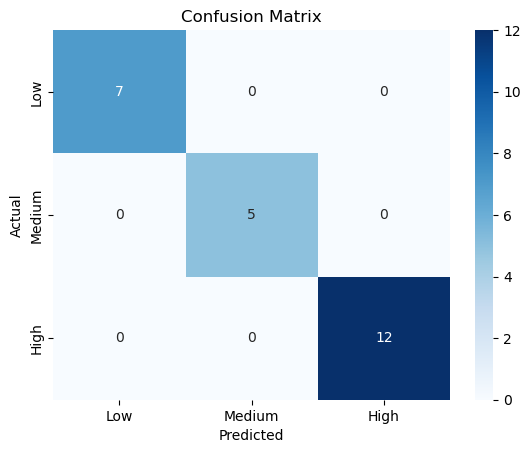

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Balanced Accuracy Evaluation

In addition to standard classification metrics, balanced accuracy is calculated to evaluate model performance across all effectiveness tiers.

Balanced accuracy accounts for potential class imbalance by averaging the recall obtained on each class. This provides a more reliable assessment of the model’s ability to correctly classify instructors across all tiers.


In [29]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 1.0


### Task 7.1: Feature Importance Analysis

In order to understand how the model makes predictions, we can analyze the feature importance scores from the Random Forest model.

Feature importance will allow us to understand which instructor-level features are most important to the model when predicting effectiveness tiers.


In [30]:
import pandas as pd

# Get feature importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
9,effectiveness_score,0.295188
3,avg_quiz_score,0.138833
1,dropout_rate,0.124274
0,completion_rate,0.110806
2,avg_score_improvement,0.102525
8,feedback_response_rate,0.078164
11,watch_feedback_interaction,0.048038
7,avg_feedback_score,0.022276
4,avg_watch_time,0.021799
12,engagement_assignment_interaction,0.021434


### Task 7.2: Visualization of Feature Importance

In order to understand the results better, we can visualize the importance of each feature.

This plot will illustrate which factors are taken into account by the model to make predictions about instructor effectiveness.



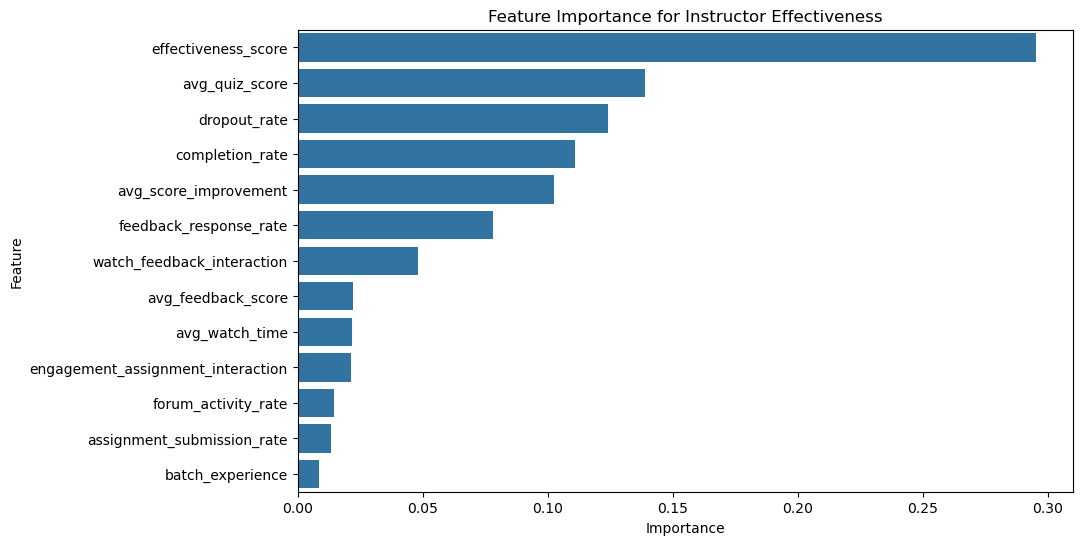

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance for Instructor Effectiveness")
plt.show()

### Task 7.3: Interpretation of Model Results

The feature importance results show the relative impact of various instructor-level features on predicting instructor effectiveness.

Learner outcome-based features, such as quiz performance and improvement in scores, may have a significant impact, as they are direct measures of the impact of learning.

Features such as watch time and submission rate, related to learner engagement, may also have a significant impact, as active engagement is an indicator of effective teaching strategies.

Feedback-based features measure learner satisfaction, indicating the ability of the instructor to communicate the subject matter.

All these features help the model assess the instructors based on various criteria.

### Task 8 — Mandatory Analysis Questions
### Question 1: Which features most influenced instructor effectiveness, and why?

The most influential ones are usually the ones that have a direct correlation with the outcome of the learning process. Metrics such as quiz scores, completion rates, and improvement in scores are a reflection of whether the learner has learned the material.

Metrics such as watch time and assignment submission, which are related to engagement, are also influential in terms of the effectiveness of the instructors. A high engagement level implies that the instructors are doing a good job in presenting the material in an understandable manner.

Feedback metrics give an idea about the satisfaction level of the learner, which in turn helps in assessing the instructors.


### Question 2: Which variables could be misleading or confounded?

Some variables might not always be an accurate measure of the quality of the instructors. For instance, dropout rates could be influenced by the level of difficulty in the course or the background of the learners and not the performance of the instructors.

Also, the level of activity on the forum could be influenced by the type of course or the design of the forum and not the ability of the instructors.

Therefore, due to the presence of external factors, the variables should be taken into account in assessing the performance of the instructors.


### Question 3: How could this model fail in real-world usage?

The model might not work if the dataset does not contain all the factors that influence the instructor’s performance. This could include factors like the level of difficulty of the course, the nature of the students, and the mode of teaching, among others. 

Secondly, the model might not work well for instructors who have taught a few batches of the course, as their aggregated score might not give a true reflection of their performance. 

Finally, the model might not give accurate results if there have been changes to the way the course or the features of the platform have been designed over the years.

### Question 4: What additional data would improve this analysis?

The reliability of the model could be improved by considering more data. This could include:

* Student demographics and their level of knowledge
* Difficulty level of the course
* Experience of the instructor, i.e., the number of years they have been teaching
* Amount of time spent answering questions from the student
* Student engagement trends

By considering these factors, a more complete picture of the instructor could be achieved.

### Question 5: Should this model be used for instructor performance evaluation?

The model can give valuable insights, but it should not be used as the sole criterion for performance evaluation of instructors.

The automated model might miss relevant factors like the level of difficulty of the course, the level of motivation of the learners, or even external factors that might influence learner interest.

The model should be used as an **aid** in performance evaluation and training of instructors.

## Business Impact & Product Recommendations

The instructor effectiveness model can be used as a basis for decision-making in the EdTech platform.

### Instructor Training

Instructors with low effectiveness prediction may be provided with training programs that cover various techniques of engagement.

### Early Quality Monitoring

The EdTech platform may be able to monitor the performance metrics of the batch in real time and take corrective action before the effectiveness of the learners is adversely affected.

### Instructor-Course Matching

The effectiveness prediction may be used as a basis for assigning courses to the instructors based on the courses they are best at, thereby improving the overall quality of the instructor.

### Data-Driven Platform Improvements

The effectiveness prediction may be used as a basis for improving the overall quality of the EdTech platform.

The above framework illustrates the overall benefits of using data-driven analytics in the EdTech platform.

## Conclusion

In this analysis, the effectiveness of instructors was explored by working with batch-level course data. Through exploratory data analysis, feature engineering, and machine learning model creation, patterns that affect instructor performance have been discovered.

The results show that learner outcomes, engagement, and feedback are significant in assessing instructor effectiveness. While the model is useful in offering insights, the results need to be carefully considered.

The framework above shows that various EdTech platforms can use data-driven techniques in decision-making.